In [1]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

import matplotlib.pyplot as plt
import fitsio
import glob

import numpy as np
import os
import gc
import numpy.lib.recfunctions as rfn
from lsst.geom import degrees
import h5py

/gpfs02/work/xiangchong.li/work/tmp/ipykernel_6702/2381941053.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


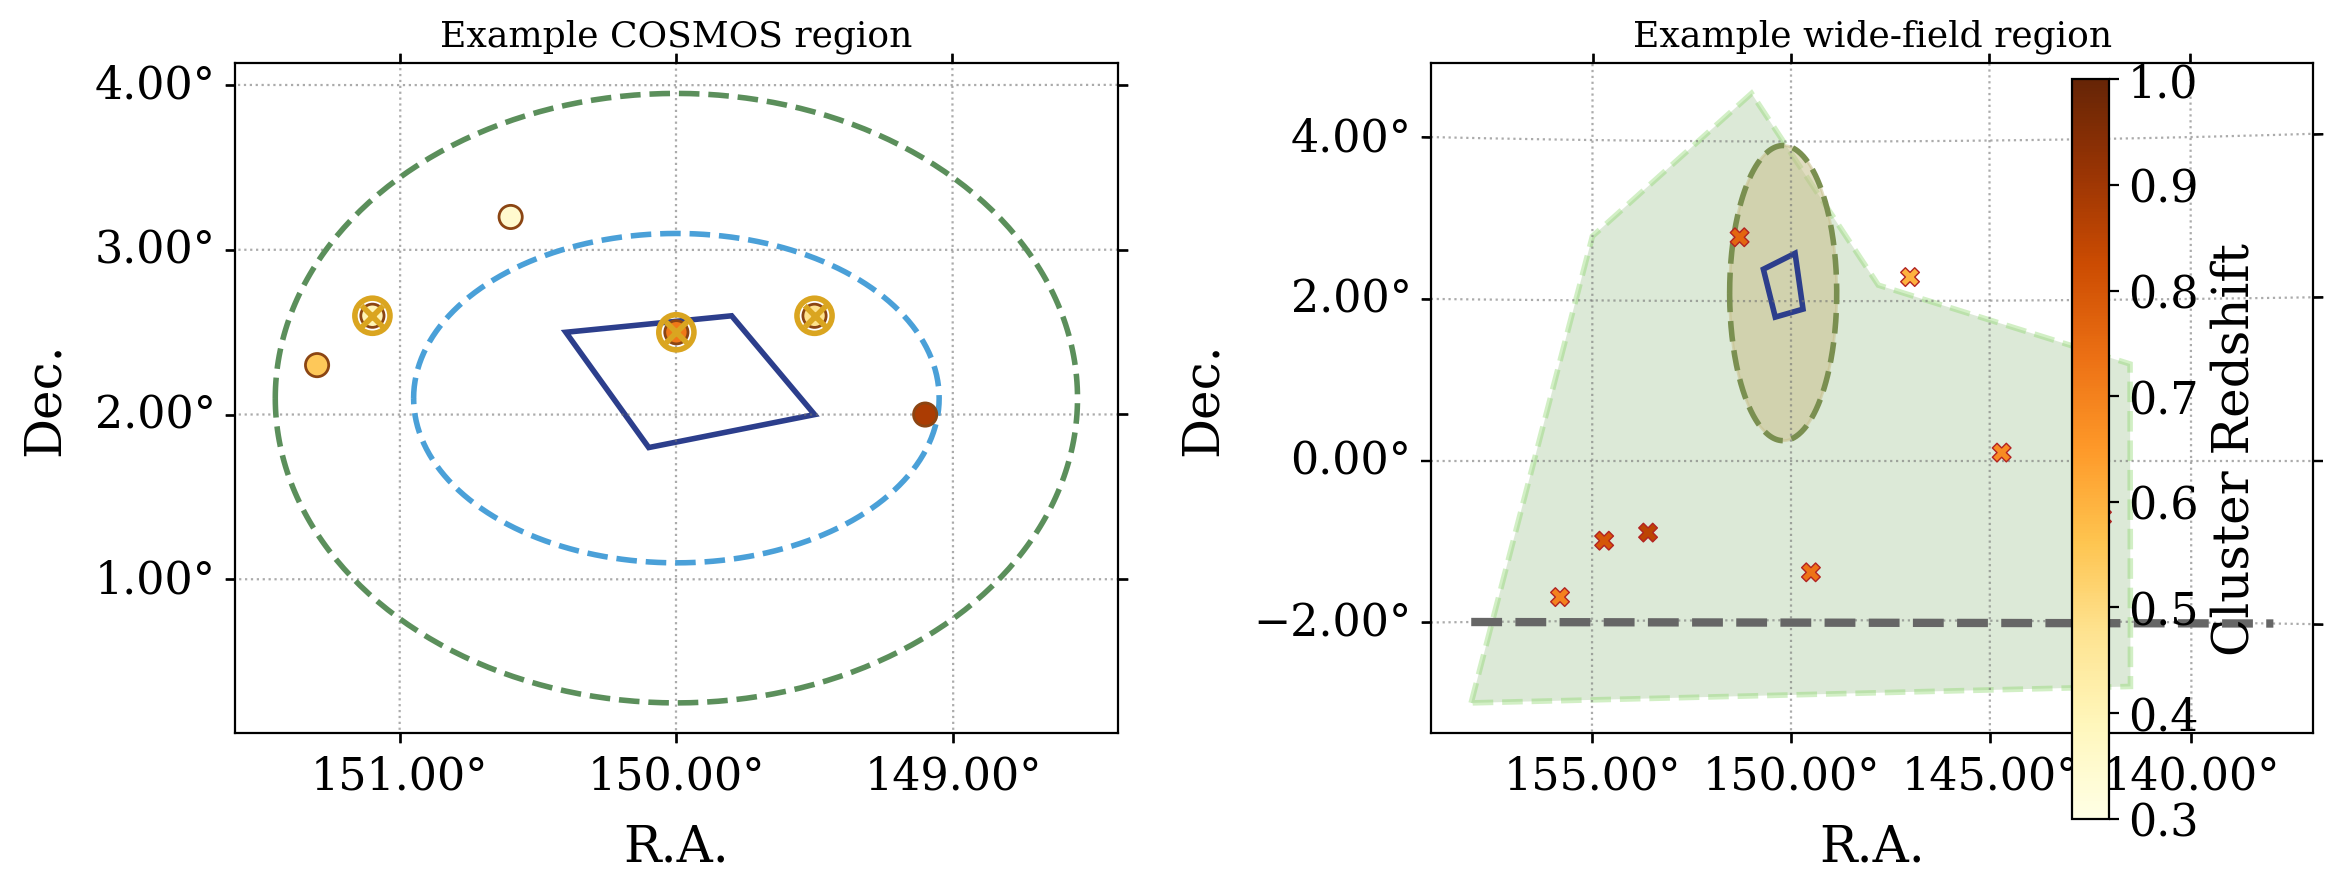

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/tan_projection_example.png'

In [177]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from astropy.wcs import WCS
from astropy import units as u
from astropy.coordinates import SkyCoord, SkyOffsetFrame
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

def make_tan_wcs(ra0_deg, dec0_deg, width_deg, height_deg, npix_x=800, npix_y=500):
    w = WCS(naxis=2)
    w.wcs.ctype = ["RA---TAN", "DEC--TAN"]
    w.wcs.crval = [ra0_deg, dec0_deg]
    w.wcs.crpix = [npix_x / 2, npix_y / 2]
    w.wcs.cdelt = np.array([-width_deg / npix_x, height_deg / npix_y])
    return w

def sky_ellipse(ra_deg, dec_deg, a_deg, b_deg, pa_deg=0.0, n=361):
    center = SkyCoord(ra_deg * u.deg, dec_deg * u.deg, frame="icrs")
    frame = SkyOffsetFrame(origin=center)
    t = np.linspace(0, 2 * np.pi, n)
    x = a_deg * np.cos(t)
    y = b_deg * np.sin(t)
    theta = np.deg2rad(pa_deg)
    xr = x * np.cos(theta) - y * np.sin(theta)
    yr = x * np.sin(theta) + y * np.cos(theta)
    c = SkyCoord(lon=xr * u.deg, lat=yr * u.deg, frame=frame)
    icrs = c.transform_to("icrs")
    return icrs.ra.deg, icrs.dec.deg

def add_world_polygon(ax, ra_vertices, dec_vertices, **kwargs):
    xy = np.column_stack([ra_vertices, dec_vertices])
    poly = Polygon(xy, closed=True, transform=ax.get_transform("world"), **kwargs)
    ax.add_patch(poly)
    return poly

def format_radec_axes(ax):
    ax.coords.grid(True, color="0.45", ls=":", lw=0.8)
    ax.coords[0].set_axislabel("R.A.")
    ax.coords[1].set_axislabel("Dec.")
    ax.coords[0].set_major_formatter("d.dd")
    ax.coords[1].set_major_formatter("d.dd")

# Example data
ra_left = np.array([151.3, 151.1, 150.6, 150.0, 149.5, 149.1])
dec_left = np.array([2.3, 2.6, 3.2, 2.5, 2.6, 2.0])
z_left = np.array([0.55, 0.40, 0.35, 0.72, 0.48, 0.88])

ra_right = np.array([155.8, 154.7, 153.6, 151.3, 149.5, 147.0, 144.7, 142.2])
dec_right = np.array([-1.7, -1.0, -0.9, 2.8, -1.4, 2.3, 0.1, -0.7])
z_right = np.array([0.70, 0.80, 0.85, 0.76, 0.73, 0.60, 0.68, 0.58])

fig = plt.figure(figsize=(12, 4.8))

wcs1 = make_tan_wcs(ra0_deg=150.1, dec0_deg=2.2, width_deg=3.4, height_deg=3.8)
ax1 = fig.add_subplot(1, 2, 1, projection=wcs1)
format_radec_axes(ax1)

wcs2 = make_tan_wcs(ra0_deg=149.5, dec0_deg=1.0, width_deg=20.0, height_deg=9.0)
ax2 = fig.add_subplot(1, 2, 2, projection=wcs2)
format_radec_axes(ax2)

# Left panel
ra, dec = sky_ellipse(150.0, 2.1, a_deg=1.45, b_deg=1.85, pa_deg=0)
ax1.plot(ra, dec, "--", lw=2, color="#5b8f5b", transform=ax1.get_transform("world"))

ra, dec = sky_ellipse(150.0, 2.1, a_deg=0.95, b_deg=1.0, pa_deg=0)
ax1.plot(ra, dec, "--", lw=2, color="#4aa0d8", transform=ax1.get_transform("world"))

ra_poly = [150.4, 149.8, 149.5, 150.1]
dec_poly = [2.5, 2.6, 2.0, 1.8]
add_world_polygon(ax1, ra_poly, dec_poly, edgecolor="#2c3e8c", facecolor="none", lw=2)

norm = Normalize(vmin=0.3, vmax=1.0)
sc1 = ax1.scatter(
    ra_left, dec_left, c=z_left, s=70, cmap="YlOrBr",
    norm=norm, edgecolor="saddlebrown", linewidth=1.0,
    transform=ax1.get_transform("world"), zorder=5
)
highlight_idx = [1, 3, 4]
ax1.scatter(
    ra_left[highlight_idx], dec_left[highlight_idx],
    facecolors="none", edgecolors="goldenrod", s=160, linewidths=2,
    transform=ax1.get_transform("world"), zorder=6
)
ax1.scatter(
    ra_left[highlight_idx], dec_left[highlight_idx],
    marker="x", color="goldenrod", s=60, linewidths=2,
    transform=ax1.get_transform("world"), zorder=7
)
ax1.set_title("Example COSMOS region", fontsize=13)

# Right panel
ra_poly = [158.0, 155.0, 151.0, 147.8, 141.5, 141.5, 158.0]
dec_poly = [-3.0,  2.8,   4.6,   2.2,   1.2,  -2.8, -3.0]
add_world_polygon(ax2, ra_poly, dec_poly,
                  facecolor="#9dc28d", edgecolor="#7fd35b",
                  alpha=0.35, lw=2, linestyle="--")

ra, dec = sky_ellipse(150.2, 2.1, a_deg=1.35, b_deg=1.85, pa_deg=0)
ax2.fill(ra, dec, color="#c8c08d", alpha=0.55, transform=ax2.get_transform("world"))
ax2.plot(ra, dec, "--", lw=2, color="#7a8f50", transform=ax2.get_transform("world"))

ra_poly = [150.7, 149.9, 149.7, 150.4]
dec_poly = [2.4, 2.6, 1.9, 1.8]
add_world_polygon(ax2, ra_poly, dec_poly, edgecolor="#2c3e8c", facecolor="none", lw=2)

ax2.plot([158.0, 138.0], [-2.0, -2.0], "--", lw=3, color="0.4",
         transform=ax2.get_transform("world"))

ax2.scatter(
    ra_right, dec_right, c=z_right, s=45, cmap="YlOrBr",
    norm=norm, marker="X", edgecolor="firebrick", linewidth=0.5,
    transform=ax2.get_transform("world"), zorder=5
)
ax2.set_title("Example wide-field region", fontsize=13)

sm = ScalarMappable(norm=norm, cmap="YlOrBr")
sm.set_array([])
cbar = fig.colorbar(sm, ax=[ax1, ax2], fraction=0.03, pad=0.02)
cbar.set_label("Cluster Redshift")

plt.tight_layout()
plt.show()


In [95]:
cat_dir = "/gpfs02/work/xiangchong.li/work/hsc_data/s23b/deepCoadd_anacal_v2/"
field_list = ["hectomap", "spring1", "spring2", "spring3", "autumn1", "autumn2"]
data = []
for field in field_list:
    print(field)
    data_a = fitsio.read(
        os.path.join(cat_dir, "fields/%s.fits" % field),
    )
    data_d = fitsio.read(
        os.path.join(cat_dir, "fields_color/%s.fits" % field),
    )
    gc.collect()    
    rail_pz_h5 = "/gpfs02/work/xiangchong.li/work/hsc_data/s23b/s23b_pz_v2.3/%s_noshear_fzboost.hdf5" %field
    with h5py.File(rail_pz_h5, "r") as f:
        zbest = np.ravel(f["ancil"]["zbest"][:])
        zmode = np.ravel(f["ancil"]["zmode"][:])
    gc.collect()
    
    mag_max = {
        "g": 27.0,
        "r": 26.0,
        "i": 24.6,
        "z": 25.0,
        "y": 25.5,
    }
    
    m_mag = np.ones(len(data_a), dtype=bool)
    for b in "grizy":
        mag = (27.0 - 2.5 * np.log10(data_a[f"{b}_flux_gauss2"]) - data_d[f"a_{b}"])
        m_mag = m_mag & (mag < mag_max[b])
    m_z = (zbest >=0.3) & (zbest < 1.5)
    m_z2 = (zmode >=0.3) & (zmode < 1.5)
    m_size = (data_a["m2"] / data_a["m0"]) > 0.05
    m_e = ((data_a["e1"] ** 2 + data_a["e2"] ** 2) < 0.3 ** 2.0)
    mm = (m_z & m_mag & m_size & m_e)
    print(np.sum(mm))
    mm = (m_z2 & m_mag & m_size & m_e)
    print(np.sum(mm))

hectomap


/gpfs02/work/xiangchong.li/work/tmp/ipykernel_24986/651792991.py:29: RuntimeWarning: invalid value encountered in log10
  mag = (27.0 - 2.5 * np.log10(data_a[f"{b}_flux_gauss2"]) - data_d[f"a_{b}"])


2039400
2294870
spring1
6712152
7554306
spring2
7151221
8070362
spring3
7624432
8590820
autumn1
6891172
7719558
autumn2
8200529
9237245


In [ ]:
cat_dir = "/gpfs02/work/xiangchong.li/work/hsc_data/s23b/deepCoadd_anacal_v2/"
field_list = ["hectomap", "spring1", "spring2", "spring3", "autumn1", "autumn2"]
data = []
mag_max = {
    "g": 27.0,
    "r": 26.0,
    "i": 24.6,
    "z": 25.0,
    "y": 25.5,
}
for field in field_list:
    print(field)
    data_a = fitsio.read(
        os.path.join(cat_dir, "fields/%s.fits" % field),
    )
    data_d = fitsio.read(
        os.path.join(cat_dir, "fields_color/%s.fits" % field),
    )
    gc.collect()    
    rail_pz_h5 = "/gpfs02/work/xiangchong.li/work/hsc_data/s23b/s23b_pz_v2.3/%s_noshear_fzboost.hdf5" %field
    with h5py.File(rail_pz_h5, "r") as f:
        zbest = np.ravel(f["ancil"]["zbest"][:])
        zmode = np.ravel(f["ancil"]["zmode"][:])
    gc.collect()
    m_mag = np.ones(len(data_a), dtype=bool)
    for b in "i":
        mag = (27.0 - 2.5 * np.log10(data_a[f"{b}_flux_gauss2"]) - data_d[f"a_{b}"])
        m_mag = m_mag & (mag < mag_max[b])
    m_z = (zbest >=0.3) & (zbest < 1.5)
    mm = (m_z & m_mag)
    mm2 = fitsio.read("/gpfs02/work/xiangchong.li/work/hsc_data/s23b/s23b_pz_v2.3/bin_autumn1_noshear.fits")[""]
    print(np.sum(mm), np.sum(mm2))

In [103]:
def _rotate(*, c, s, phi_rad):
    # Do rotation
    cp = np.cos(phi_rad)
    sp = np.sin(phi_rad)
    return c * cp - s * sp, c * sp + s * cp

def get_response_average(*, catalog, response, dm1_plus1=1.0, sel_response=0.0, det_response=0.0):
    response_average = np.average(catalog["wsel"] * (
        response["response"] * dm1_plus1
        + np.sqrt(2.0) / 2.0 * (
            catalog["e22c"] * catalog["e1"]
            + catalog["e22s"] * catalog["e2"]
        )
    )) + sel_response + det_response
    return response_average

def get_shear(
    *,
    catalog, response,
    sim=None, dm1_plus1=1.0, 
    do_rotation=True, 
    sel_response=0.0, det_response=0.0,
):
    """
    Compute per-object shear estimators (g1, g2) from measured spin moments and
    a (scalar) shear response, optionally applying a known rotation and
    optionally including first-order simulated shear terms.
    Parameters
    ----------
    catalog : mapping or numpy structured array
        Per-object measurements. Must provide fields/keys:
        - "wsel" : weight for selection and detection
        - "e1", "e2" : spin-2 ellipticity-like components
        - "e22c", "e22s" : spin-2 components used in the response correction
        - "e44c", "e44s" : spin-4 components used in the response correction
    response : mapping
        Response information. Must provide:
        - "response" : base (scalar or per-object) shear response term.
    sim : mapping or None, optional
        If provided, enables two behaviors:
        - rotation: uses `sim["rot_angle"]` (radians) when `do_rotation=True`
        - injected shear correction: uses `sim["g1_sim"]` and `sim["g2_sim"]`
          to include first-order terms in the numerator.
        If None, the estimator is computed without injected-shear corrections.
    dm1_plus1 : float, optional
        Multiplicative blinding factor applied to `response["response"]`.
        Use 1.0 for no extra scaling.
    do_rotation : bool, optional
        If True and `sim` is not None, rotate all spin components by
        `rot_angle` (spin-2 uses 2*rot_angle; spin-4 uses 4*rot_angle).
        If False (or `sim` is None), no rotation is applied.
    sel_response : float, optional
        Additional selection response contribution. In the current
        implementation it is added to the response denominator and, when `sim`
        is provided, contributes to the numerator as `g*_sim * sel_response`.
    det_response : float, optional
        Additional selection response contribution. In the current
        implementation it is added to the response denominator and, when `sim`
        is provided, contributes to the numerator as `g*_sim * det_response`.
    Returns
    -------
    g1 : numpy.ndarray
        Per-object shear estimator for the first component.
    g2 : numpy.ndarray
        Per-object shear estimator for the second component.
    """
    if do_rotation and (sim is not None):
        rot_angle = sim["rot_angle"]
    else:
        rot_angle = 0.0
    # rotation
    e1, e2 = _rotate(c=catalog["e1"], s=catalog["e2"], phi_rad=2.0*rot_angle)
    e22c, e22s = _rotate(
        c=catalog["e22c"], s=catalog["e22s"], phi_rad=2.0*rot_angle,
    )
    e44c, e44s = _rotate(
        c=catalog["e44c"], s=catalog["e44s"], phi_rad=4.0*rot_angle,
    )
    # shear
    de1_dg1 = (
        response["response"] * dm1_plus1
        - np.sqrt(3.0) * e44c + np.sqrt(2.0) * e22c * e1
    )
    de2_dg2 = (
        response["response"] * dm1_plus1
        + np.sqrt(3.0) * e44c + np.sqrt(2.0) * e22s * e2
    )
    de1_dg2 = -np.sqrt(3.0) * e44s + np.sqrt(2.0) * e22s * e1
    de2_dg1 = -np.sqrt(3.0) * e44s + np.sqrt(2.0) * e22c * e2
    # include detection and selection response
    if sim is None:
        we1 = catalog["wsel"] * e1
        we2 = catalog["wsel"] * e2
    else:
        we1 = catalog["wsel"] * (
            e1 + de1_dg1 * sim["g1_sim"]
            + de1_dg2 * sim["g2_sim"]
        ) + sim["g1_sim"] * (sel_response + det_response)
        we2 = catalog["wsel"] * (
            e2 + de2_dg1 * sim["g1_sim"]
            + de2_dg2 * sim["g2_sim"]
        ) + sim["g2_sim"] * (sel_response + det_response)
    response_average = get_response_average(
        catalog=catalog, response=response,
        dm1_plus1=dm1_plus1, sel_response=sel_response, 
        det_response=det_response,
    )
    print(response_average)
    g1 = we1 / response_average
    g2 = we2 / response_average
    return g1, g2

In [165]:
cat_dir = "/gpfs02/work/xiangchong.li/work/hsc_data/s23b/deepCoadd_anacal_v2/"
field_list = ["hectomap", "spring1", "spring2", "spring3", "autumn1", "autumn2"]
data = []
mag_max = {
    "g": 27.0,
    "r": 26.0,
    "i": 24.6,
    "z": 25.0,
    "y": 25.5,
}
field = "spring3"
data_a = fitsio.read(
    os.path.join(cat_dir, "fields/%s.fits" % field),
)
data_d = fitsio.read(
    os.path.join(cat_dir, "fields_color/%s.fits" % field),
)

In [171]:
dg1 = 0.02
emax = 0.3
smin = 0.05

mag_max = {
    "g": 27.0,
    "r": 26.0,
    "i": 24.6,
    "z": 25.0,
    "y": 25.5,
}

m_mag = np.ones(len(data_a), dtype=bool)
for b in "grizy":
    mag = (27.0 - 2.5 * np.log10(data_a[f"{b}_flux_gauss2"] + dg1 * data_a[f"{b}_dflux_gauss2_dg1"]) - data_d[f"a_{b}"])
    m_mag = m_mag & (mag < mag_max[b]) 
rtrace= ((data_a["m2"] + data_a["dm2_dg1"] * dg1) / (data_a["m0"] + data_a["dm0_dg1"] * dg1))
m_size = (rtrace > smin) & (rtrace < smax)
esq = (data_a["e1"] ** 2 + 2.0 * dg1 * data_a["de1_dg1"] * data_a["e1"] + data_a["e2"] ** 2 + 2.0 * dg1 * data_a["de2_dg1"] * data_a["e2"])
m_e = (esq< emax ** 2.0)
mm1 = (m_mag & m_size & m_e)

dg1 = -0.02
m_mag = np.ones(len(data_a), dtype=bool)
for b in "grizy":
    mag = (27.0 - 2.5 * np.log10(data_a[f"{b}_flux_gauss2"] + dg1 * data_a[f"{b}_dflux_gauss2_dg1"]) - data_d[f"a_{b}"])
    m_mag = m_mag & (mag < mag_max[b])
rtrace= ((data_a["m2"] + data_a["dm2_dg1"] * dg1) / (data_a["m0"] + data_a["dm0_dg1"] * dg1))
m_size = (rtrace > smin) & (rtrace < smax)
esq = (data_a["e1"] ** 2 + 2.0 * dg1 * data_a["de1_dg1"] * data_a["e1"] + data_a["e2"] ** 2 + 2.0 * dg1 * data_a["de2_dg1"] * data_a["e2"])
m_e = (esq< emax ** 2.0)
mm2 = (m_mag & m_size & m_e)

/gpfs02/work/xiangchong.li/work/tmp/ipykernel_6702/1616660045.py:15: RuntimeWarning: invalid value encountered in log10
  mag = (27.0 - 2.5 * np.log10(data_a[f"{b}_flux_gauss2"] + dg1 * data_a[f"{b}_dflux_gauss2_dg1"]) - data_d[f"a_{b}"])
/gpfs02/work/xiangchong.li/work/tmp/ipykernel_6702/1616660045.py:26: RuntimeWarning: invalid value encountered in log10
  mag = (27.0 - 2.5 * np.log10(data_a[f"{b}_flux_gauss2"] + dg1 * data_a[f"{b}_dflux_gauss2_dg1"]) - data_d[f"a_{b}"])


In [172]:
print(np.sum(mm1) / 2737904)
r_sel = (np.average(data_a["wsel"][mm1] * data_a["e1"][mm1]) - np.average(data_a["wsel"][mm2] * data_a["e1"][mm2]))/ 0.04
print(r_sel)

3.775769347646959
-0.05194549393579578


In [173]:
Rave = np.average(
    0.5*(
        data_a["wsel"][mm1] * data_a["de1_dg1"][mm1] + data_a["dwsel_dg1"][mm1] * data_a["e1"][mm1] + 
        data_a["wsel"][mm1] * data_a["de2_dg2"][mm1] + data_a["dwsel_dg2"][mm1] * data_a["e2"][mm1]
    )
)
print(0.5 * (np.average(data_a["dwsel_dg1"][mm1] * data_a["e1"][mm1] + data_a["dwsel_dg2"][mm1] * data_a["e2"][mm1])))
print(Rave)

-0.011939967690959905
0.3056373785347649


In [174]:
print(np.std(data_a["wsel"][mm1] * data_a["e1"][mm1]) / (Rave + r_sel))

0.3668590712216473


In [176]:
(0.29 / 0.36) ** 2.0 * 15

9.733796296296298